In [8]:
import pandas as pd
import numpy as np


from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
import matplotlib.pyplot as plt


In [ ]:
## load dataset 

In [9]:
df = pd.read_csv("knn_telecom.csv")

In [10]:
le_gender = LabelEncoder()
le_plan = LabelEncoder()

df["Gender"] = le_gender.fit_transform(df["Gender"])
df["PlanType"] = le_plan.fit_transform(df["PlanType"])

In [11]:
X = df.drop("Churn", axis=1)
Y = df["Churn"]

In [ ]:
## feature scaling (required fro KNN)

In [12]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
## cross Validation setup

In [13]:
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

k_values = range(1,8)
cv_scores = []

In [ ]:
## train and Evaluate for different k values 

In [14]:
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn,X_scaled,Y,cv=skf,scoring="accuracy")
    cv_scores.append(scores.mean())

In [ ]:
## display RESULTS 

In [15]:
for k, score in zip(k_values,cv_scores):
    print("k = ",k,"| Cross Validation Accuracy = ", round(score,3))
     

k =  1 | Cross Validation Accuracy =  0.967
k =  2 | Cross Validation Accuracy =  0.953
k =  3 | Cross Validation Accuracy =  0.973
k =  4 | Cross Validation Accuracy =  0.96
k =  5 | Cross Validation Accuracy =  0.973
k =  6 | Cross Validation Accuracy =  0.953
k =  7 | Cross Validation Accuracy =  0.953


In [ ]:
## Select best k 

In [16]:
best_k = k_values[np.argmax(cv_scores)]
print("\nBest K:",best_k)


Best K: 3


In [ ]:
## plot result

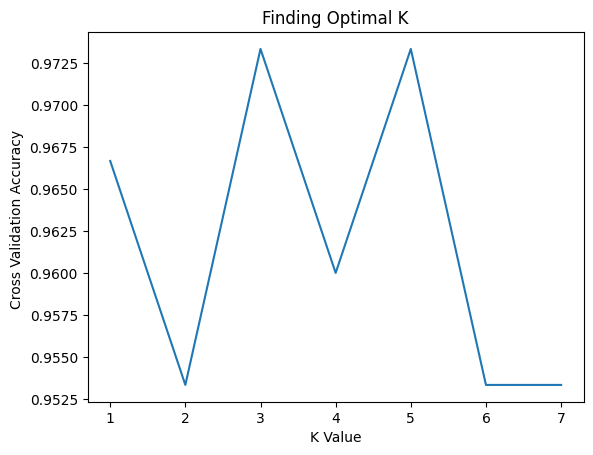

In [17]:
plt.plot(k_values,cv_scores)
plt.xlabel("K Value")
plt.ylabel("Cross Validation Accuracy ")
plt.title("Finding Optimal K")
plt.show()